# Lags of every region when decoding the solenoids

In [3]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import r2_score, make_scorer

from tqdm import tqdm

import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors


In [2]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [37]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
all_kinematics = ['left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip']


df = dt.add_bhv(df)
# df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
# df = dt.balance_classes(df, 'values_Sol_direction')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)
targets = df.values_Sol_direction.values.tolist()

In [38]:
areas = ['bhv', 'MOp', 'SSp', 'CP', 'VAL']
scores = {}
for area in areas:
    if area != 'bhv':
        scores[area], times = decode.moving_window_decoding(
            np.stack(perturb_td[f"{area}_rates_pca"]),
            targets,
            window_length_bin=10,
            step_bin=1,
            cv=5
        )
    else:
        scores[area], times = decode.moving_window_decoding(
            np.stack(perturb_td[area]),
            targets,
            window_length_bin=10,
            step_bin=1,
            cv=5
        )

  0%|          | 0/242 [00:00<?, ?it/s]

100%|██████████| 242/242 [00:06<00:00, 35.31it/s]


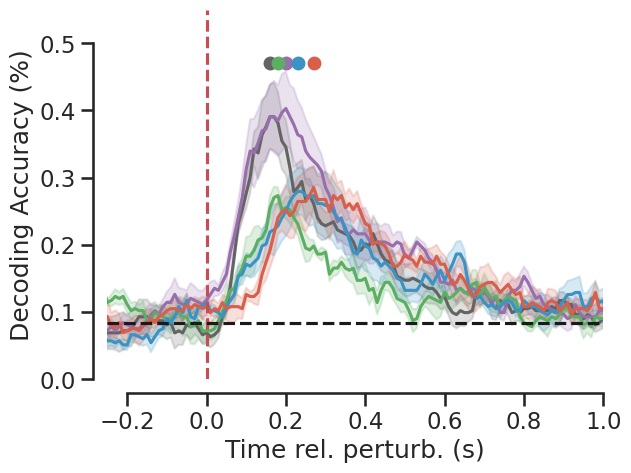

In [65]:
from tools.params import colors
import scipy
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        line, _ = vizutils.shaded_errorbar(ax, times-1, scores[area], 
                                        errorStat=scipy.stats.sem, label=area, color=getattr(colors, f"{area}_light"))
        # ax.axvline(x=times[np.argmax(scores[area].mean(axis=-1))]-1, color=getattr(colors, f"{area}_light"), linestyle='dashed')
        peak_time = times[np.argmax(scores[area].mean(axis=-1))]-1
        ax.plot(peak_time, 0.47, marker='o', color=getattr(colors, f"{area}_light"))

    ax.axvline(x=0, color='r', linestyle='dashed', label='perturb')
    ax.axhline(y=1/12, color='k', linestyle='dashed', label='chance')
    ax.set_xlabel('Time rel. perturb. (s)')
    ax.set_ylabel('Decoding Accuracy (%)')
    # ax.legend()
    ax.set_ylim([0, 0.55])
    ax.set_xlim([-0.25, 1])

(-0.5, 1.25)

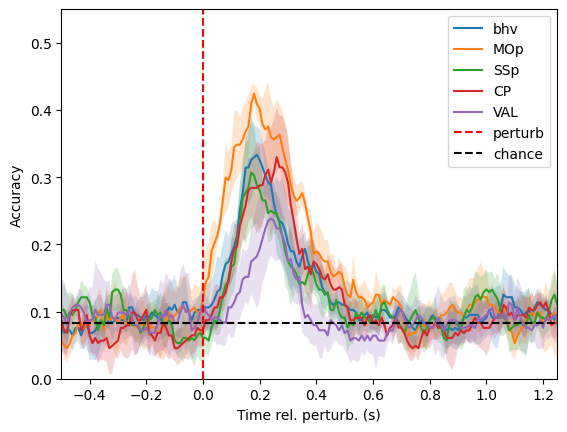

In [41]:
fig, ax = plt.subplots()
for area in areas:
    line, _ = vizutils.shaded_errorbar(ax, times-1, scores[area], 
                                    errorStat=np.std, label=area)
ax.axvline(x=0, color='r', linestyle='dashed', label='perturb')
ax.axhline(y=1/12, color='k', linestyle='dashed', label='chance')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim([0, 0.55])
ax.set_xlim([-0.5, 1.25])

In [50]:
scores["MOp"].mean(axis=-1).shape

(242,)

In [66]:
def find_peak_lag_in_array(array, times):
    return times[np.argmax(array.mean(axis=-1))]

def find_peak_lag_in_area_dict(cv_area_dict, times):
    lags_dict = {}
    for area in cv_area_dict.keys():
        lags_dict[area] = find_peak_lag_in_array(cv_area_dict[area], times)
    return lags_dict

def compute_cv_scores_all_areas(df, areas=['bhv', 'MOp', 'SSp', 'CP', 'VAL']):
    targets = df.values_Sol_direction.values.tolist()
    scores = {}
    for area in areas:
        if area != 'bhv':
            scores[area], times = decode.moving_window_decoding(
                np.stack(df[f"{area}_rates_pca"]),
                targets,
                window_length_bin=10,
                step_bin=1,
                cv=5
            )
        else:
            scores[area], times = decode.moving_window_decoding(
                np.stack(df[area]),
                targets,
                window_length_bin=10,
                step_bin=1,
                cv=5
            )
    return scores, times

def prep_df_and_get_lags(df, balance=True, rel_start= -100, rel_end=150, areas=['bhv', 'MOp', 'SSp', 'CP', 'VAL']):
    df = pyal.select_trials(df, df.trial_name == 'trial')
    df = dt.add_pca_df(df, n_components=30)
    if balance:
        df = dt.balance_classes(df, 'values_Sol_direction')
    perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = rel_start, rel_end= rel_end)
    scores_dict, times = compute_cv_scores_all_areas(perturb_td, areas)
    times = times - abs(rel_start)*0.01
    lags_dict = find_peak_lag_in_area_dict(scores_dict, times)

    return lags_dict, scores_dict, times


def compute_lags_scores_all_sessions(sessions: list, areas=['bhv', 'MOp', 'SSp', 'CP', 'VAL']):
    all_kinematics = ['left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
        'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
        'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
        'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
        'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
        'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
        'tail_middle', 'tail_tip']
    sessions_dict = {}
    for session in sessions:
        areas_ = areas.copy()
        sessions_dict[session] = {}
        print(f"Processing session {session}")
        handler = decode.DecodingDataHandler(
            data_dir='/data/bnd-data/raw/', 
            session=session,
            combine_time_bins=False
        )
        df = handler.df.copy()
        try: 
            df = dt.add_bhv(df, all_kinematics)
        except Exception as e:
            print(f"Error trying to add behaviour: {e}")
            areas_.remove('bhv')
        print(areas_)
        sessions_dict[session]["lags"], sessions_dict[session]["scores"], sessions_dict[session]["times"] = prep_df_and_get_lags(df, areas=areas_)
    return sessions_dict
        

In [67]:
sessions_dict = compute_lags_scores_all_sessions(['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00',
                                                  'M063_2025_03_12_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30'])

Processing session M061_2025_03_04_10_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['VAL_spikes', 'SSp_spikes', 'all_spikes', 'CP_spikes', 'MOp_spikes', 'GPe_spikes']


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.8529411764706% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.8529411764706% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.8529411764706% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.8529411764706% of trials
  warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (240, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (59, 60000)
Resulting all_spikes ephys data shape is (NxT): (53, 60000)
Resulting CP_spikes ephys data shape is (NxT): (225, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (206, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (112, 60000)
Error trying to add behaviour: 'right_knee'
['MOp', 'SSp', 'CP', 'VAL']


100%|██████████| 242/242 [00:02<00:00, 87.10it/s]


Processing session M061_2025_03_05_14_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
['VAL_spikes', 'all_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes']


...

100%|██████████| 242/242 [00:02<00:00, 85.81it/s]


Processing session M063_2025_03_14_15_30
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['VAL_spikes', 'SSp_spikes', 'all_spikes', 'CP_spikes', 'MOp_spikes']


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (260, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (92, 60000)
Resulting all_spikes ephys data shape is (NxT): (38, 60000)
Resulting CP_spikes ephys data shape is (NxT): (329, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (161, 60000)
Error trying to add behaviour: 'right_knee'
['MOp', 'SSp', 'CP', 'VAL']


100%|██████████| 242/242 [00:02<00:00, 94.30it/s]


Text(0.5, 1.0, 'Time of peak decoding solenoid direction')

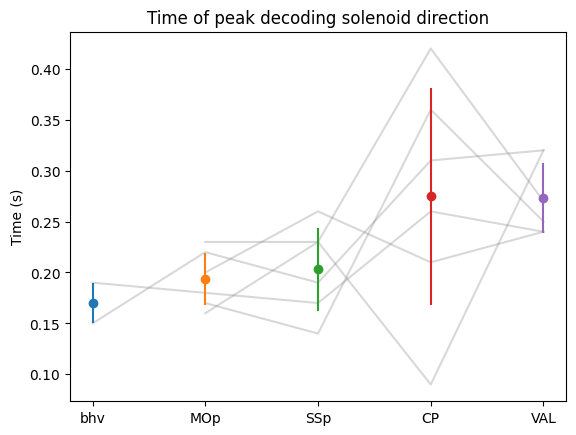

In [68]:
fig, ax = plt.subplots()
sessions = ['M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M061_2025_03_04_10_00',
            'M063_2025_03_12_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30']

for sess in sessions:
    # if bhv
    ax.plot(sessions_dict[sess]['lags'].keys(), sessions_dict[sess]['lags'].values(), color='gray', alpha=0.3)
for area in areas:
    area_lag = []
    for sess in sessions:
        if area not in sessions_dict[sess]['lags'].keys():
            continue
        area_lag.append(sessions_dict[sess]['lags'][area])
    area_lag = np.array(area_lag)
    ax.errorbar(x=area, y=area_lag.mean(), yerr=area_lag.std(), fmt='-o')


ax.set_ylabel('Time (s)')
ax.set_title('Time of peak decoding solenoid direction')



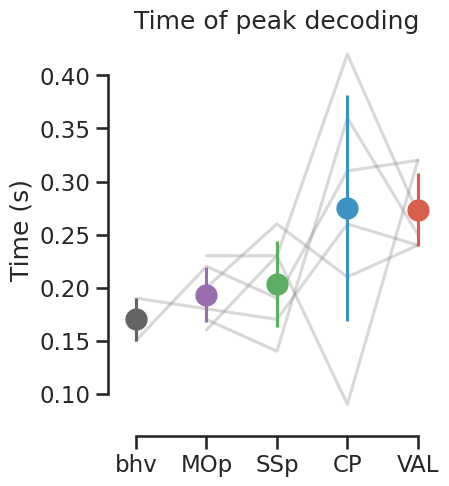

In [87]:
sessions = ['M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M061_2025_03_04_10_00',
            'M063_2025_03_12_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30']

with vizutils.apply_plot_style():
    fig, ax = plt.subplots(figsize=(4, 5))


    for sess in sessions:
        # if bhv
        ax.plot(sessions_dict[sess]['lags'].keys(), sessions_dict[sess]['lags'].values(), color='gray', alpha=0.3)
    for area in areas:
        area_lag = []
        for sess in sessions:
            if area not in sessions_dict[sess]['lags'].keys():
                continue
            area_lag.append(sessions_dict[sess]['lags'][area])
        area_lag = np.array(area_lag)
        ax.errorbar(x=area, y=area_lag.mean(), yerr=area_lag.std(), fmt='-o',
                    color=getattr(colors, f"{area}_light"), markersize=15)
    ax.set_title('Time of peak decoding')
    ax.set_ylabel('Time (s)')



# How many dimensions for each area?

In [2]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [3]:
n_comp_ = 100

random_states = range(99)
df_ = handler.df.copy()
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=n_comp_, pca_fields=['MOp_rates', 'CP_rates'])
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')


# MOP
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -10, rel_end= 150)
global_scores_mop = []
global_scores_cp = []


for random_state in tqdm(random_states):
    perturb_td = dt.balance_classes(perturb_td, 'values_Sol_direction', random_state=random_state)
    targets = perturb_td.values_Sol_direction.values.tolist()
    area='MOp'

    n_trials, n_times, n_components = np.stack(perturb_td[f"{area}_rates_pca"]).shape
    scores = []
    for n_comp in range(n_components):
        data = np.stack(perturb_td[f"{area}_rates_pca"])[:, :, :n_comp+1]
        score = cross_val_score(
            GaussianNB(), 
            np.stack(data).reshape(-1, n_times * (n_comp+1)), 
            targets,
            scoring="accuracy",
            cv=3
        )
        scores.append(score.mean())
    scores = np.array(scores)
    global_scores_mop.append(scores)

    scores = []
    area='CP'

    for n_comp in range(n_components):
        data = np.stack(perturb_td[f"{area}_rates_pca"])[:, :, :n_comp+1]
        score = cross_val_score(
            GaussianNB(), 
            np.stack(data).reshape(-1, n_times * (n_comp+1)), 
            targets,
            scoring="accuracy",
            cv=3
        )
        scores.append(score.mean())
    scores = np.array(scores)
    global_scores_cp.append(scores)

global_scores_mop = np.array(global_scores_mop)
global_scores_cp = np.array(global_scores_cp)

Dropped 11 of 333 rows (3.30%).


100%|██████████| 99/99 [10:42<00:00,  6.49s/it]


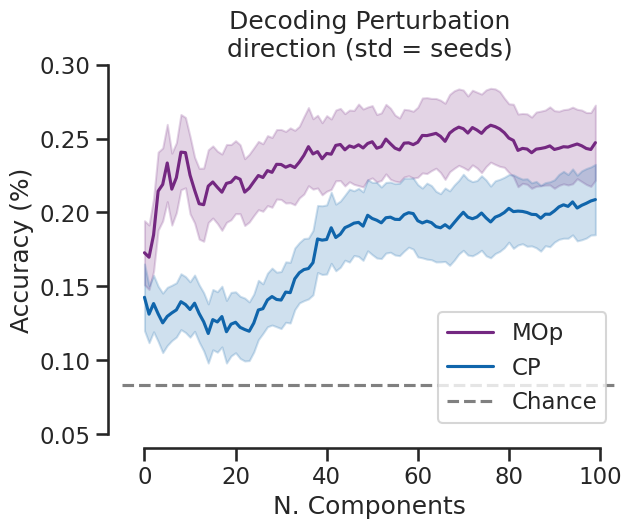

In [38]:
with vizutils.apply_plot_style('talk'):
    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(
        ax, 
        global_scores_mop.T,
        label='MOp',
        color=getattr(colors, 'MOp')
    )
    vizutils.shaded_errorbar(
        ax, 
        global_scores_cp.T,
        label='CP',
        color=getattr(colors, 'CP')
    )
    ax.set_ylim(0.05, 0.3)
    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel('N. Components')
    ax.axhline(1/12, color='grey', linestyle='dashed', label='Chance')
    ax.set_title('Decoding Perturbation\ndirection (std = seeds)')
    ax.legend()
plt.show()

In [147]:
n_comp_ = 69

random_states = range(99)
df_ = handler.df.copy()
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=n_comp_, pca_fields=['SSp_rates', 'VAL_rates'])
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')


# MOP
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -10, rel_end= 150)
global_scores_ssp = []
global_scores_val = []


for random_state in tqdm(random_states):
    perturb_td = dt.balance_classes(perturb_td, 'values_Sol_direction', random_state=random_state)
    targets = perturb_td.values_Sol_direction.values.tolist()
    area='SSp'

    n_trials, n_times, n_components = np.stack(perturb_td[f"{area}_rates_pca"]).shape
    scores = []
    for n_comp in range(n_components):
        data = np.stack(perturb_td[f"{area}_rates_pca"])[:, :, :n_comp+1]
        score = cross_val_score(
            GaussianNB(), 
            np.stack(data).reshape(-1, n_times * (n_comp+1)), 
            targets,
            scoring="accuracy",
            cv=3
        )
        scores.append(score.mean())
    scores = np.array(scores)
    global_scores_ssp.append(scores)

    scores = []
    area='VAL'

    for n_comp in range(n_components):
        data = np.stack(perturb_td[f"{area}_rates_pca"])[:, :, :n_comp+1]
        score = cross_val_score(
            GaussianNB(), 
            np.stack(data).reshape(-1, n_times * (n_comp+1)), 
            targets,
            scoring="accuracy",
            cv=3
        )
        scores.append(score.mean())
    scores = np.array(scores)
    global_scores_val.append(scores)

global_scores_ssp = np.array(global_scores_ssp)
global_scores_val = np.array(global_scores_val)

Dropped 11 of 333 rows (3.30%).


100%|██████████| 99/99 [05:26<00:00,  3.30s/it]


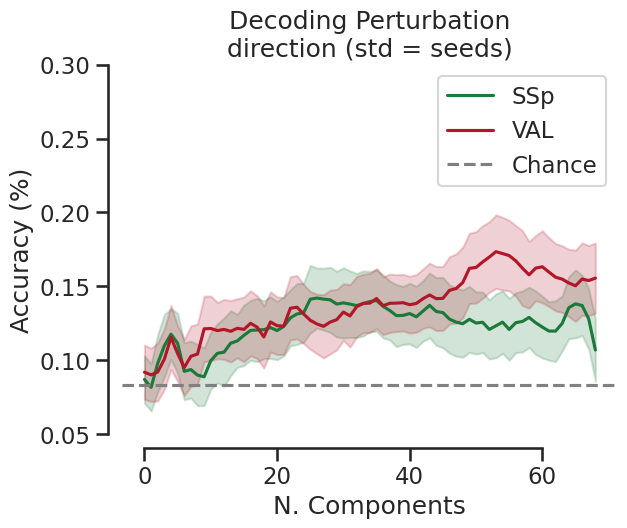

In [152]:
with vizutils.apply_plot_style('talk'):
    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(
        ax, 
        global_scores_ssp.T,
        label='SSp',
        color=getattr(colors, 'SSp')
    )
    vizutils.shaded_errorbar(
        ax, 
        global_scores_val.T,
        label='VAL',
        color=getattr(colors, 'VAL')
    )
    ax.set_ylim(0.05, 0.3)
    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel('N. Components')
    ax.axhline(1/12, color='grey', linestyle='dashed', label='Chance')
    ax.set_title('Decoding Perturbation\ndirection (std = seeds)')
    ax.legend()
plt.show()

In [106]:
areas = ['bhv', 'MOp', 'SSp', 'CP', 'VAL']
scores = {}
df_ = handler.df.copy()
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_bhv(df)
df = dt.add_pca_df(df, n_components=50)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)
perturb_td = dt.balance_classes(perturb_td, 'values_Sol_direction')
targets = perturb_td.values_Sol_direction.values.tolist()


for area in areas:
    if area != 'bhv':
        scores[area], times = decode.moving_window_decoding(
            np.stack(perturb_td[f"{area}_rates_pca"]),
            targets,
            window_length_bin=10,
            step_bin=1,
            cv=5
        )
    else:
        scores[area], times = decode.moving_window_decoding(
            np.stack(perturb_td[area]),
            targets,
            window_length_bin=10,
            step_bin=1,
            cv=5
        )

Dropped 11 of 333 rows (3.30%).


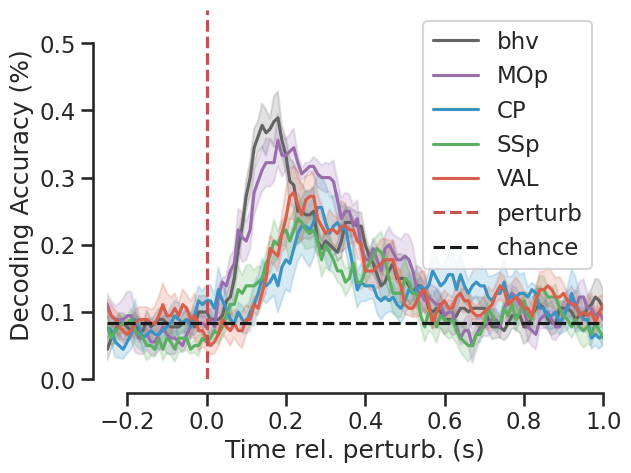

In [108]:
areas =['bhv', 'MOp', 'CP', 'SSp', 'VAL']
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        line, _ = vizutils.shaded_errorbar(ax, times-1, scores[area], 
                                        errorStat=scipy.stats.sem, label=area, color=getattr(colors, f"{area}_light"))
        # ax.plot(peak_time, 0.47, marker='o', color=getattr(colors, f"{area}_light"))

    ax.axvline(x=0, color='r', linestyle='dashed', label='perturb')
    ax.axhline(y=1/12, color='k', linestyle='dashed', label='chance')
    ax.set_xlabel('Time rel. perturb. (s)')
    ax.set_ylabel('Decoding Accuracy (%)')
    ax.legend()
    ax.set_ylim([0, 0.55])
    ax.set_xlim([-0.25, 1])
plt.show()

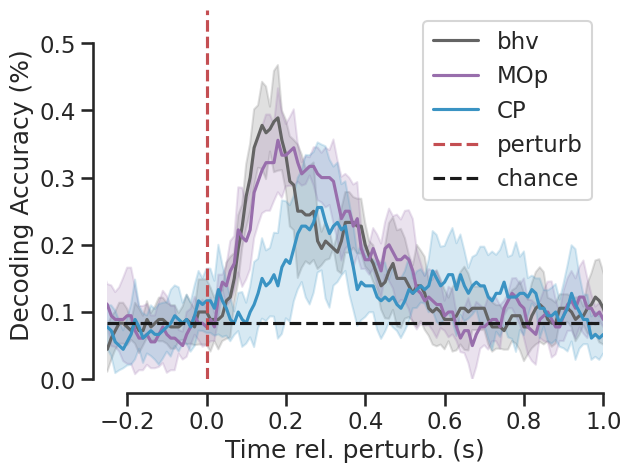

In [45]:
areas =['bhv', 'MOp', 'CP']
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        line, _ = vizutils.shaded_errorbar(ax, times-1, scores[area], 
                                        errorStat=np.std, label=area, color=getattr(colors, f"{area}_light"))
        # ax.plot(peak_time, 0.47, marker='o', color=getattr(colors, f"{area}_light"))

    ax.axvline(x=0, color='r', linestyle='dashed', label='perturb')
    ax.axhline(y=1/12, color='k', linestyle='dashed', label='chance')
    ax.set_xlabel('Time rel. perturb. (s)')
    ax.set_ylabel('Decoding Accuracy (%)')
    ax.legend()
    ax.set_ylim([0, 0.55])
    ax.set_xlim([-0.25, 1])
plt.show()

In [43]:
np.stack(perturb_td[f"{area}_rates_pca"]).shape

(180, 251, 50)

In [57]:
areas = ['MOp', 'CP']
scores = {}
df_ = handler.df.copy()
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_bhv(df)
df = dt.add_pca_df(df, n_components=50)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)
perturb_td = dt.balance_classes(perturb_td, 'values_Sol_direction')
targets = perturb_td.values_Sol_direction.values.tolist()

n_comp = 50
for area in areas:
    print(f"Processing area: {area}")
    scores_ = []
    for n_comp in tqdm(range(n_comp)):
        score, times = decode.moving_window_decoding(
            np.stack(perturb_td[f"{area}_rates_pca"])[:, :, :n_comp+1],
            targets,
            window_length_bin=10,
            step_bin=1,
            cv=5,
        )
        scores_.append(score.mean(axis=1))
    scores[area] = np.array(scores_)


Dropped 11 of 333 rows (3.30%).
Processing area: MOp


100%|██████████| 50/50 [01:19<00:00,  1.59s/it]


Processing area: CP


100%|██████████| 49/49 [01:17<00:00,  1.59s/it]


In [150]:
scores

array([0.10555556, 0.11666667, 0.08888889, 0.15555556, 0.16666667,
       0.13888889, 0.12777778, 0.12777778, 0.11666667, 0.13888889,
       0.15      , 0.12222222, 0.12222222, 0.12222222, 0.12777778,
       0.13333333, 0.14444444, 0.14444444, 0.11666667, 0.11666667,
       0.12222222, 0.11666667, 0.13888889, 0.13333333, 0.12777778,
       0.11111111, 0.11666667, 0.11111111, 0.11111111, 0.11111111,
       0.12222222, 0.12222222, 0.11666667, 0.13333333, 0.13333333,
       0.13333333, 0.13888889, 0.12777778, 0.13333333, 0.13888889,
       0.11666667, 0.12777778, 0.13333333, 0.13888889, 0.12222222,
       0.14444444, 0.12222222, 0.14444444, 0.15      , 0.15555556,
       0.13888889, 0.13888889, 0.15      , 0.16111111, 0.16111111,
       0.16666667, 0.15      , 0.17222222, 0.17222222, 0.17222222,
       0.16111111, 0.16666667, 0.16666667, 0.17222222, 0.15555556,
       0.16666667, 0.16111111, 0.16666667, 0.16666667])

In [82]:
times[np.arange(192, step=50)]

array([0.1, 0.6, 1.1, 1.6])

In [148]:
with vizutils.apply_plot_style():
    fig, axes = plt.subplots(1, 2, sharex='all', sharey='all', figsize=(10, 4))
    for area, ax in zip(['MOp', 'CP'], axes):
        im = ax.imshow(scores[area], cmap='viridis', aspect='auto')
        # cbar = fig.colorbar(im, ax=ax)
        ax.set_xticks(np.arange(scores["MOp"].shape[1], step=50))         # Tick positions (0–9)
        ax.set_xticklabels(np.round(times[np.arange(scores["MOp"].shape[1], step=50)]-0.5, 1))         
        # Tick positions (0–9)
        ax.set_xlim(0, 150)
        ax.axvline(x=45, color='red')
        im.set_clim(0, 0.36)
        ax.set_title(area)
        ax.set_xlabel('Time (s)')

        ax.set_ylabel('N. components')
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Accuracy (%)')
    plt.show()

# with vizutils.apply_plot_style():
#     fig, ax = plt.subplots()
#     im = ax.imshow(scores["CP"], cmap='viridis', aspect='auto')
#     cbar = fig.colorbar(im, ax=ax)
#     ax.set_xticks(np.arange(scores["MOp"].shape[1], step=50))         # Tick positions (0–9)
#     ax.set_xticklabels(np.round(times[np.arange(scores["MOp"].shape[1], step=50)]-0.5, 1))         
#     # Tick positions (0–9)
#     # ax.set_xlim(0, 150)
#     # fig.colorbar(im, ax=ax, label='Value')
#     ax.axvline(x=45, color='red')
#     im.set_clim(0, 0.36)
#     plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

# Understanding the dimensionality during perturbation

In [3]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [6]:
np.concatenate(df.MOp_rates.values).shape

(193201, 178)

In [7]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')

Dropped 11 of 333 rows (3.30%).


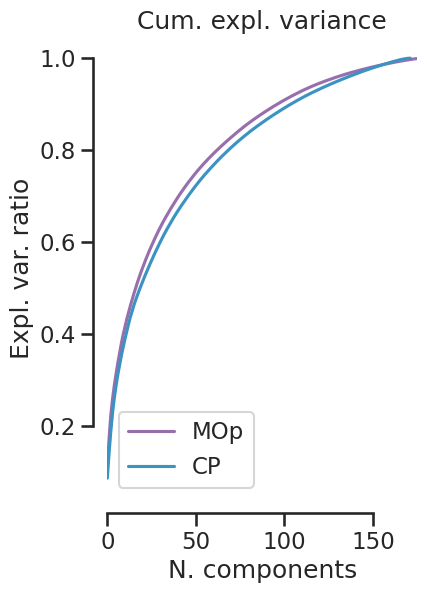

In [36]:
expl_vars_mop = dim.get_explained_variance_ratio(np.concatenate(df.MOp_rates.values))
expl_vars_cp = dim.get_explained_variance_ratio(np.concatenate(df.CP_rates.values))

with vizutils.apply_plot_style():
    fig, ax = plt.subplots(figsize=(4, 6))
    ax.plot(np.cumsum(expl_vars_mop), color=getattr(colors, 'MOp_light'), label='MOp')
    ax.plot(np.cumsum(expl_vars_cp), color=getattr(colors, 'CP_light'), label='CP')
    ax.set_xlim(0, 175)
    ax.set_xlabel('N. components')
    ax.set_ylabel('Expl. var. ratio')
    ax.set_title('Cum. expl. variance')
    ax.legend()
plt.show()

In [22]:
dim.pca_pr(np.concatenate(df.MOp_rates.values))

37.17509330118228

In [23]:
dim.pca_pr(np.concatenate(df.CP_rates.values))

45.12997222468809

## Dimensionality

In [58]:
res = {}
areas = ['MOp', 'SSp', 'CP', 'VAL']
for area in areas:
    res[area] = dim.get_pr_for_subsets_of_neurons(
        np.concatenate(df[f"{area}_rates"].values),
        step=5
    )


100%|██████████| 33/33 [00:53<00:00,  1.61s/it]


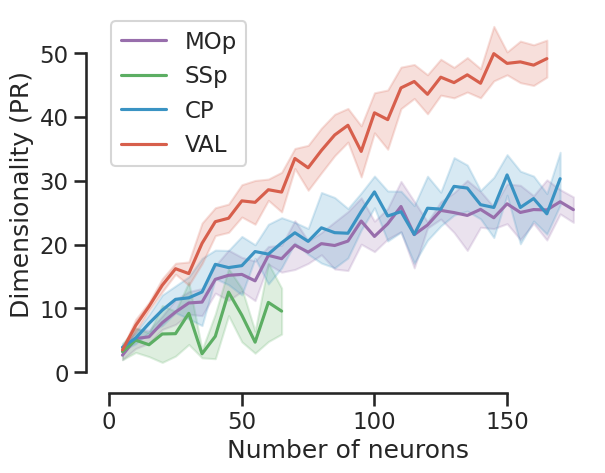

In [62]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        vizutils.shaded_errorbar(
            ax, 
            x=np.arange(5, np.concatenate(df[f"{area}_rates"].values).shape[1] + 1, 5),
            y=res[area],
            label=area,
            color=getattr(colors, f"{area}_light"))
    ax.set_ylabel('Dimensionality (PR)')
    ax.set_xlabel('Number of neurons')
    ax.legend()

## Decoding

In [122]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.balance_classes(df, 'values_Sol_direction')
df = dt.add_pca_df(df)
df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -10, rel_end= 100)
targets = perturb_td.values_Sol_direction.values.tolist()


Dropped 11 of 333 rows (3.30%).


In [123]:
res = {}
areas = ['bhv', 'MOp', 'SSp', 'CP', 'VAL']
for area in areas:
    if area != 'bhv':
        data = np.stack(perturb_td[f"{area}_rates_pca"])
    else:
        data = np.stack(perturb_td['bhv'])
    n_trials, n_times, n_components = data.shape
    res[area] = cross_val_score(
        GaussianNB(), 
        np.stack(data).reshape(-1, n_times * (n_components)), 
        targets,
        scoring="accuracy",
        cv=5
    )

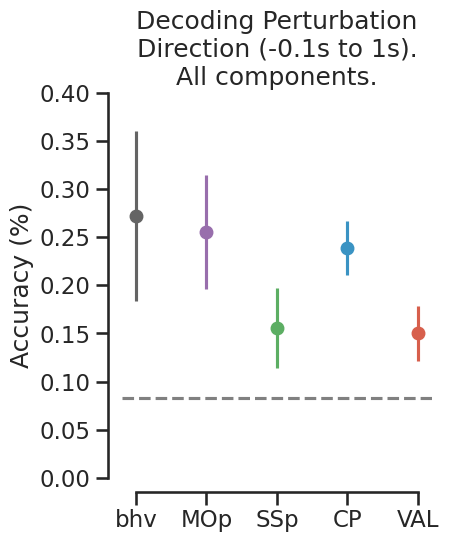

In [124]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots(figsize=(4, 5))
    for area in areas:
        ax.errorbar(
            x=area,
            y=res[area].mean(),
            yerr=res[area].std(),
            fmt='o',
            color=getattr(colors, f"{area}_light")
            )
    ax.axhline(y=1/12, color='grey', linestyle='dashed')
    ax.set_ylim(0, 0.4)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Decoding Perturbation\nDirection (-0.1s to 1s).\nAll components.')

(180, 4830)

# Behaviour to MOp / SSp?

In [1]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


NameError: name 'decode' is not defined

In [83]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
# df = dt.balance_classes(df, 'values_Sol_direction')
df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end= 200)
# perturb_td = df.copy()

Dropped 11 of 333 rows (3.30%).


In [84]:
bhv = np.concatenate(perturb_td.bhv.values)
mop = np.concatenate(perturb_td.MOp_rates_pca.values)
ssp = np.concatenate(perturb_td.SSp_rates_pca.values)

# X=bhv.reshape(180, -1)
# y=mop.reshape(180, -1)

In [55]:
default_scorer = make_scorer(r2_score, multioutput="variance_weighted")
custom_scorer = make_scorer(decode.custom_r2_func, multioutput="variance_weighted")

In [85]:
shifts = np.arange(-20, 21, step=1)
scores = []
for shift in tqdm(shifts):
    y = dim._roll_array(mop, shift=shift)
    score = cross_val_score(Ridge(alpha=0.1), bhv, y, cv=5, scoring=custom_scorer)
    scores.append(score)

scores = np.array(scores)

  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [00:58<00:00,  1.42s/it]


In [107]:
np.max(scores.mean(axis=1))

0.10159872169330175

In [105]:
shifts[np.argmax(scores.mean(axis=1))]
# shifts[np.argmax(scores_intertrial.mean(axis=1))]

2

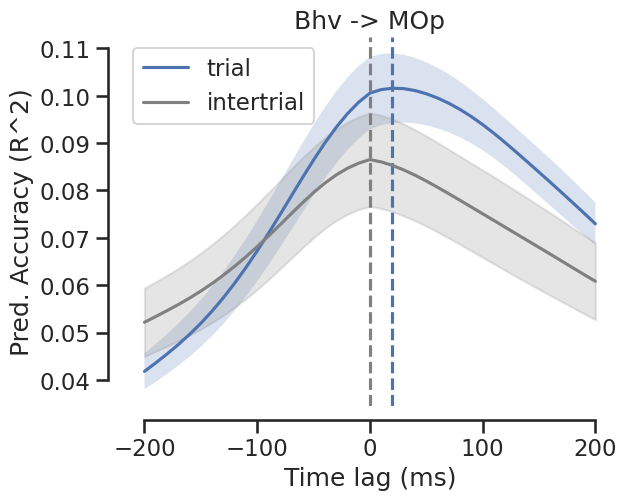

In [ ]:
# peak_value = np.arg
errorStat = scipy.stats.sem
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(ax, shifts*10, scores, label='trial', errorStat=errorStat)
    ax.axvline(shifts[np.argmax(scores.mean(axis=1))]*10, color='b', linestyle='dashed')
    vizutils.shaded_errorbar(ax, shifts*10, scores_intertrial, label='intertrial', errorStat=errorStat, color='grey')
    ax.axvline(shifts[np.argmax(scores_intertrial.mean(axis=1))]*10, color='grey', linestyle='dashed')
    ax.set_xlabel('Time lag (ms)')
    ax.set_ylabel('Pred. Accuracy (R^2)')
    ax.set_title('Bhv -> MOp')
    ax.legend()

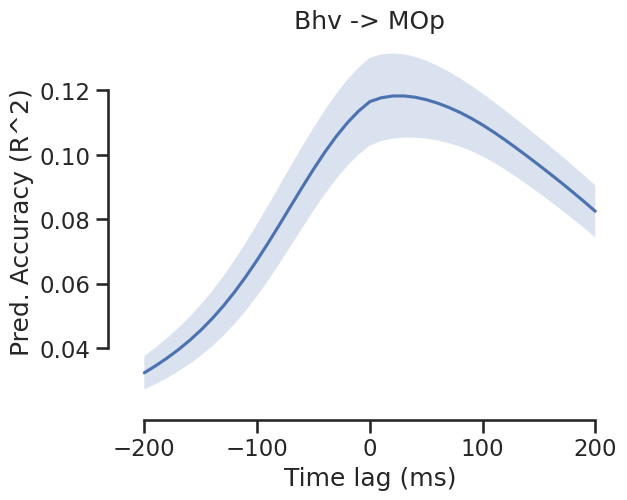

In [ ]:
# peak_value = np.arg
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(ax, shifts*10, scores)

    ax.set_xlabel('Time lag (ms)')
    ax.set_ylabel('Pred. Accuracy (R^2)')
    ax.set_title('Bhv -> MOp')

## More refined?

In [109]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
# df = dt.balance_classes(df, 'values_Sol_direction')
df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 125)


Dropped 11 of 333 rows (3.30%).


In [88]:
bhv = np.stack(perturb_td.bhv.values)
mop = np.stack(perturb_td.MOp_rates_pca.values)
ssp = np.stack(perturb_td.SSp_rates_pca.values)
cp = np.stack(perturb_td.CP_rates_pca.values)
val = np.stack(perturb_td.VAL_rates_pca.values)
bhv.shape

(322, 201, 62)

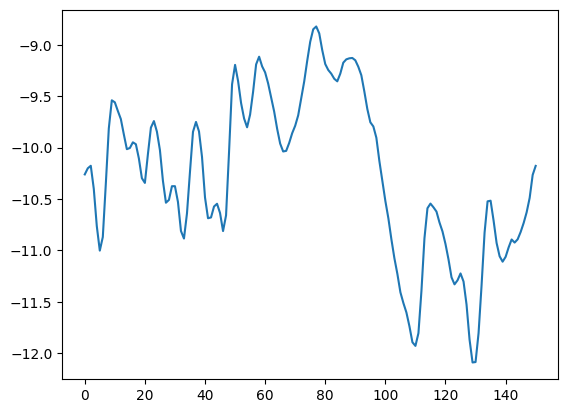

In [6]:
plt.plot(bhv[0, :, 4])

In [19]:
custom_scorer = decode.get_custom_scorer()

In [5]:

def regression_moving_window(
        X,
        y,
        max_time_bin=None,
        min_time_bin=0,
        window_length_bin=50,
        step_bin=5,
        cv=5,
        bin_size=0.01,
        scorer=decode.get_custom_scorer(),
        alpha=0.05
    ):

    scores = []
    if max_time_bin is None:
        max_time_bin = X.shape[1]

    for t in tqdm(np.arange(max_time_bin - min_time_bin + 1 - window_length_bin, step=step_bin)):
        X_, y_ = X[:, t : t + window_length_bin, :], y[:, t : t + window_length_bin, :]
        X_, y_ = X_.reshape(-1, X_.shape[1] * X_.shape[2]), y_.reshape(-1, y_.shape[1] * y_.shape[2])
        score = cross_val_score(Ridge(alpha=alpha, solver='svd'), X_, y_, scoring=scorer, cv=cv)
        scores.append(score)

    scores = np.array(scores)
    time_points = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin)

    return scores, time_points * bin_size


In [ ]:
scores_bhv_mop, times = regression_moving_window(
        bhv,
        mop[:, :, :50],
        window_length_bin=20,
        step_bin=1,
        cv=5
    )
scores_bhv_cp, times = regression_moving_window(
        bhv,
        cp[:, :, :50],
        window_length_bin=20,
        step_bin=1,
        cv=5
    )
scores_bhv_ssp, times = regression_moving_window(
        bhv,
        ssp[:, :, :50],
        window_length_bin=20,
        step_bin=1,
        cv=5
    )
scores_bhv_val, times = regression_moving_window(
        bhv,
        val[:, :, :50],
        window_length_bin=20,
        step_bin=1,
        cv=5
    )

  0%|          | 0/132 [00:00<?, ?it/s]

100%|██████████| 132/132 [00:48<00:00,  2.73it/s]


In [54]:
scores_bhv_val, times = regression_moving_window(
        bhv,
        val[:, :, :50],
        window_length_bin=20,
        step_bin=1,
        cv=5
    )

  0%|          | 0/132 [00:00<?, ?it/s]

100%|██████████| 132/132 [00:46<00:00,  2.84it/s]


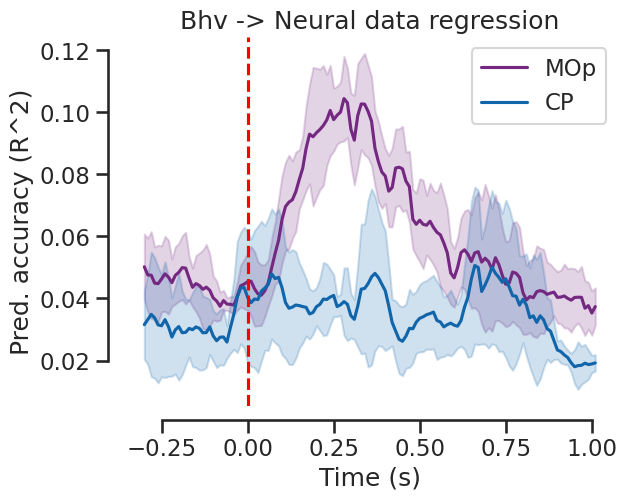

In [ ]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_mop, label='MOp', color=getattr(colors, 'MOp'))
    vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_cp, label='CP', color=getattr(colors, 'CP'))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (R^2)')
    ax.legend()
    ax.set_title('Bhv -> Neural data regression')



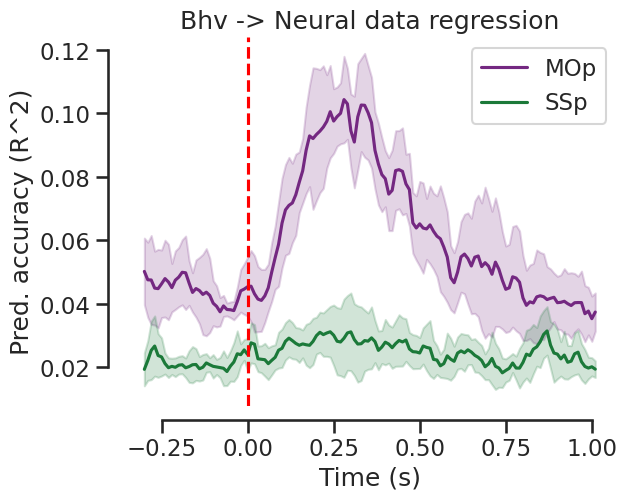

In [36]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_mop, label='MOp', color=getattr(colors, 'MOp'))
    vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_ssp, label='SSp', color=getattr(colors, 'SSp'))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (R^2)')
    ax.legend()
    ax.set_title('Bhv -> Neural data regression')



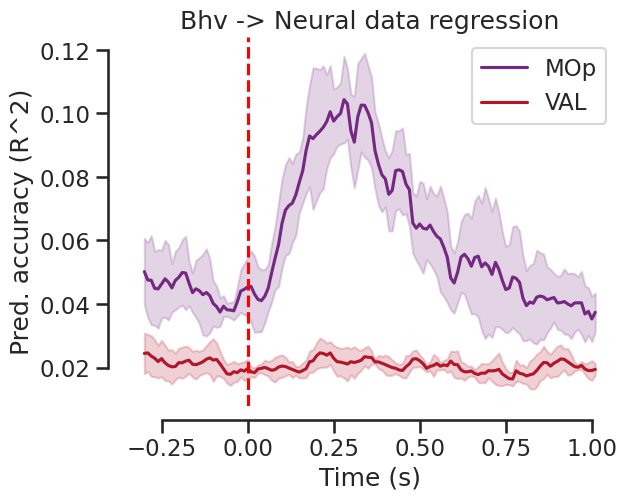

In [55]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_mop, label='MOp', color=getattr(colors, 'MOp'))
    vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_val, label='VAL', color=getattr(colors, 'VAL'))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (R^2)')
    ax.legend()
    ax.set_title('Bhv -> Neural data regression')



In [112]:
scores_neural_to_bhv = {}
areas = ['MOp', 'SSp', 'CP', 'VAL']
for area in areas:
    scores, times = regression_moving_window(
            np.stack(perturb_td[f"{area}_rates_pca"].values)[:, :, :],
            bhv,
            window_length_bin=20,
            step_bin=1,
            cv=5
        )
    scores_neural_to_bhv[area] = scores


  0%|          | 0/157 [00:00<?, ?it/s]

100%|██████████| 157/157 [02:11<00:00,  1.19it/s]


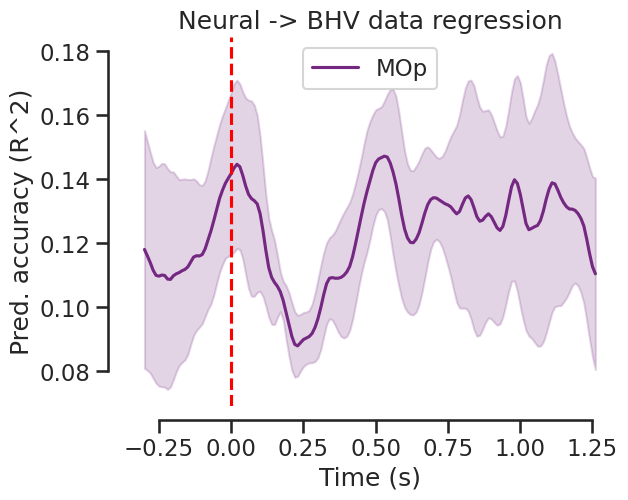

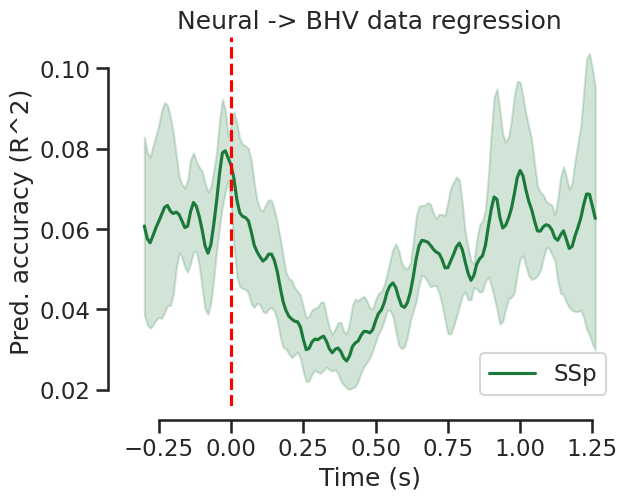

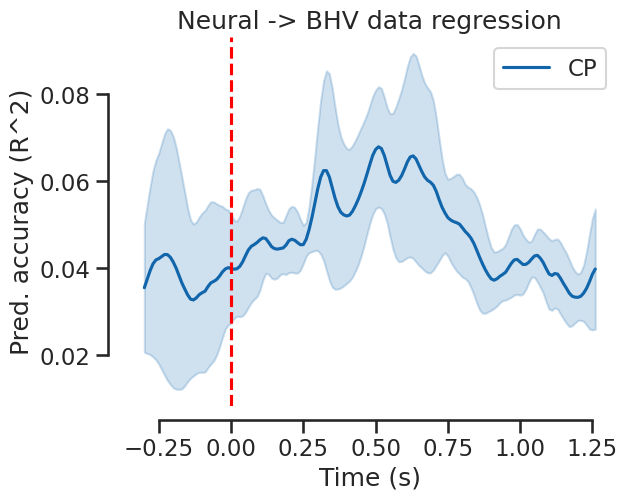

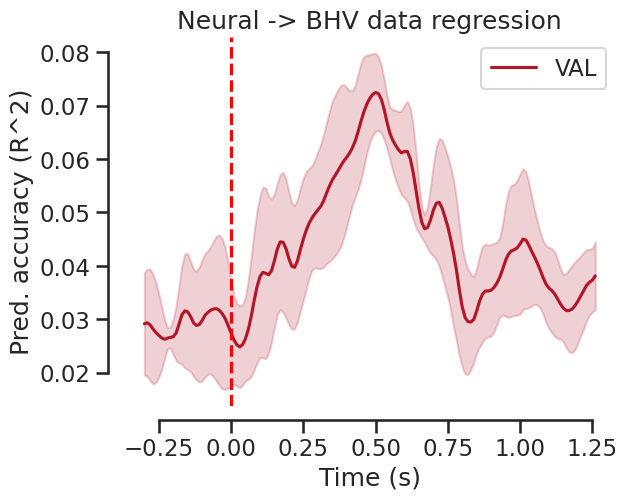

In [114]:
for area in areas:

    with vizutils.apply_plot_style():
        fig, ax = plt.subplots()


        vizutils.shaded_errorbar(ax, times-0.5, scores_neural_to_bhv[area], label=area, 
                                 color=getattr(colors, area))
    
        ax.axvline(0, color='red', linestyle='dashed')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Pred. accuracy (R^2)')
        ax.legend()
        ax.set_title('Neural -> BHV data regression')
    



In [ ]:
scores_neural_to_bhv_ = {}
areas = ['MOp']
for area in areas:
    scores, times = regression_moving_window(
            np.stack(perturb_td[f"{area}_rates_pca"].values)[:, :, :50],
            bhv,
            window_length_bin=20,
            step_bin=1,
            cv=5
        )
    scores_neural_to_bhv_[area] = scores


100%|██████████| 157/157 [01:01<00:00,  2.56it/s]


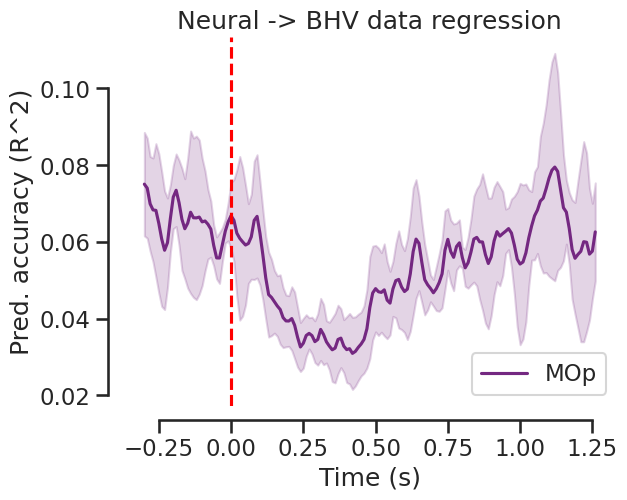

In [117]:
with vizutils.apply_plot_style():
        fig, ax = plt.subplots()


        vizutils.shaded_errorbar(ax, times-0.5, scores_neural_to_bhv['MOp'], label=area, 
                                 color=getattr(colors, area))
    
        ax.axvline(0, color='red', linestyle='dashed')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Pred. accuracy (R^2)')
        ax.legend()
        ax.set_title('Neural -> BHV data regression')

In [119]:
scores_bhv_mop, times = regression_moving_window(
        bhv,
        mop[:, :, :],
        window_length_bin=20,
        step_bin=5,
        cv=5
    )
scores_bhv_cp, times = regression_moving_window(
        bhv,
        cp[:, :, :],
        window_length_bin=20,
        step_bin=5,
        cv=5
    )
scores_bhv_ssp, times = regression_moving_window(
        bhv,
        ssp[:, :, :],
        window_length_bin=20,
        step_bin=5,
        cv=5
    )
scores_bhv_val, times = regression_moving_window(
        bhv,
        val[:, :, :],
        window_length_bin=20,
        step_bin=5,
        cv=5
    )

  0%|          | 0/37 [00:00<?, ?it/s]

100%|██████████| 37/37 [01:05<00:00,  1.78s/it]


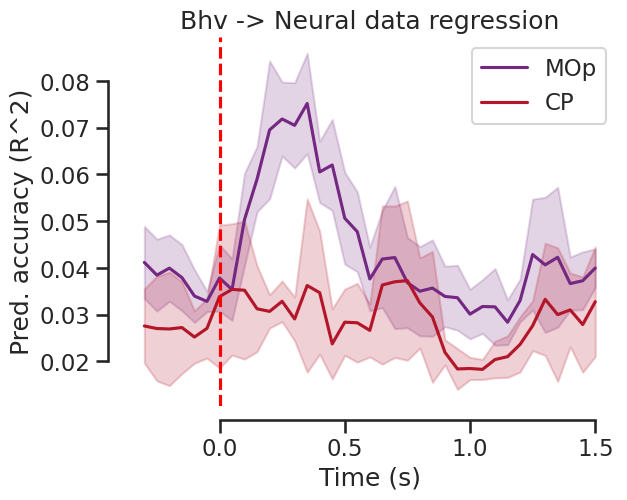

In [124]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_mop, label='MOp', color=getattr(colors, 'MOp'))
    vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_cp, label='CP', color=getattr(colors, 'VAL'))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (R^2)')
    ax.legend()
    ax.set_title('Bhv -> Neural data regression')



## What is the best keypoint to decode the solenoid?

In [6]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.balance_classes(df, 'values_Sol_direction')
targets = df.values_Sol_direction.values.tolist()

Dropped 11 of 333 rows (3.30%).


In [7]:
keypoints = [
            "left_ankle",
            "left_elbow",
            "left_foot",
            "left_knee",
            "left_paw",
            "left_shoulder",
            "left_wrist",
            "right_ankle",
            "right_elbow",
            "right_foot",
            "right_knee",
            "right_paw",
            "right_shoulder",
            "right_wrist",
            "shoulder_center",
            "tail_base",
            "tail_middle",
            "tail_tip",
        ]

In [39]:
scores_per_keypoint = {}
for keypoint in tqdm(keypoints):
    df = dt.add_bhv(df, bhv_fields=[keypoint])
    perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -10, rel_end= 100)
    data = np.stack(perturb_td.bhv.values)
    scores = cross_val_score(GaussianNB(), data.reshape(-1, data.shape[1] * data.shape[2]),
                             targets, scoring='accuracy', cv=5)
    scores_per_keypoint[keypoint] = scores

scores_per_keypoint = dict(
    sorted(scores_per_keypoint.items(), key=lambda item: sum(item[1]) / len(item[1]), reverse=True)
)

  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:06<00:00,  2.73it/s]


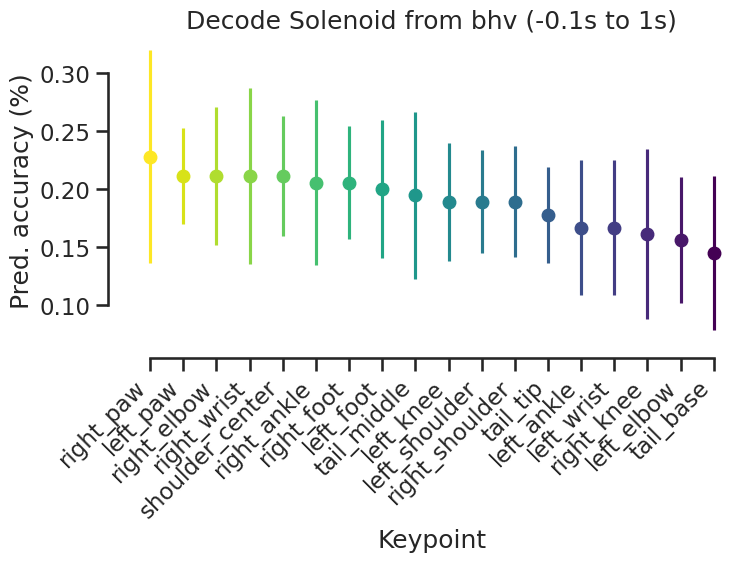

In [49]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots(figsize=(8, 4))

    # Prepare data
    keys = list(scores_per_keypoint.keys())
    means = [np.mean(v) for v in scores_per_keypoint.values()]
    sems  = [np.std(v) for v in scores_per_keypoint.values()]

    # Get viridis colours
    colors = plt.cm.viridis(np.linspace(1, 0, len(keys)))

    # Plot each point individually with its colour
    for x, y, yerr, c in zip(keys, means, sems, colors):
        ax.errorbar(x, y, yerr=yerr, fmt='o', color=c)

    ax.set_xlabel('Keypoint')
    ax.set_ylabel('Pred. accuracy (%)')
    # Read current labels (as text)
    labels = [tick.get_text() for tick in ax.get_xticklabels()]

    # Re-set them with rotation
    # plt.tight_layout()
    ax.set_title('Decode Solenoid from bhv (-0.1s to 1s)')
ax.set_xticklabels(labels, rotation=45, ha='right')

plt.show()


In [51]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.balance_classes(df, 'values_Sol_direction')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)

targets = df.values_Sol_direction.values.tolist()

Dropped 11 of 333 rows (3.30%).


In [64]:
scores_per_keypoint_across_time = {}
for keypoint in tqdm(keypoints):
    scores_per_keypoint_across_time[keypoint], times = decode.moving_window_decoding(
                np.stack(perturb_td[keypoint].values),
                targets,
                window_length_bin=20,
                step_bin=1,
                cv=5
            )

  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:24<00:00,  1.36s/it]


In [68]:
scores_per_keypoint_across_time = dict(
    sorted(
        scores_per_keypoint_across_time.items(),
        key=lambda item: np.max(np.mean(item[1], axis=1)),
        reverse=True
    )
)

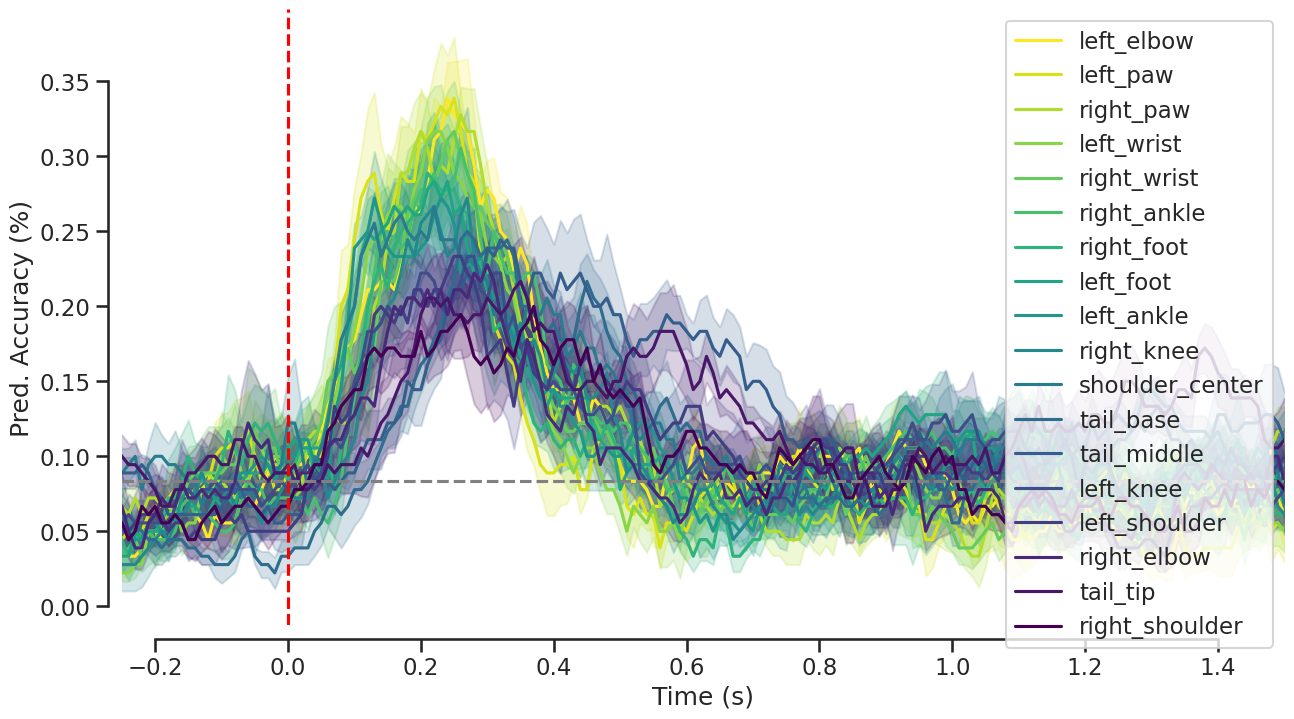

In [79]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots(figsize=(15, 8))
    colors = plt.cm.viridis(np.linspace(1, 0, len(keypoints)))

    for (keypoint, value), color in zip(scores_per_keypoint_across_time.items(), colors):
        vizutils.shaded_errorbar(ax, times-0.5, value, color=color, label=keypoint, errorStat=scipy.stats.sem)
    ax.legend()
    ax.set_ylabel('Pred. Accuracy (%)')
    ax.set_xlabel('Time (s)')
    ax.axhline(1/12, color='grey', linestyle='dashed')
    ax.axvline(0, color='red', linestyle='dashed', label='Chance')
    ax.set_xlim(-0.25, 1.5)


    

## Predicting only one keypoint

In [13]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
# df = dt.balance_classes(df, 'values_Sol_direction')
df = dt.add_bhv(df, bhv_fields=['left_elbow', 'left_paw', 'left_wrist', 'right_paw', 'right_wrist', 'right_ankle'])
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)
bhv = np.stack(perturb_td.bhv.values)


Dropped 11 of 333 rows (3.30%).


In [14]:
scores_neural_to_bhv = {}
areas = ['MOp', 'VAL', 'SSp', 'CP']
for area in areas:
    scores, times = regression_moving_window(
            np.stack(perturb_td[f"{area}_rates_pca"].values)[:, :, :],
            bhv,
            window_length_bin=20,
            step_bin=1,
            cv=5
        )
    scores_neural_to_bhv[area] = scores


100%|██████████| 232/232 [02:39<00:00,  1.45it/s]


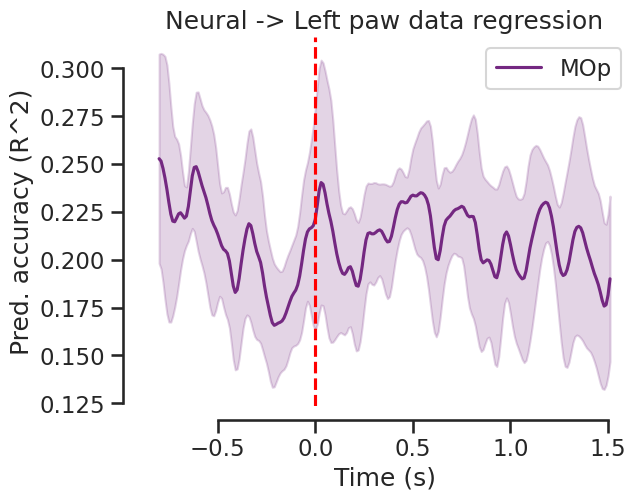

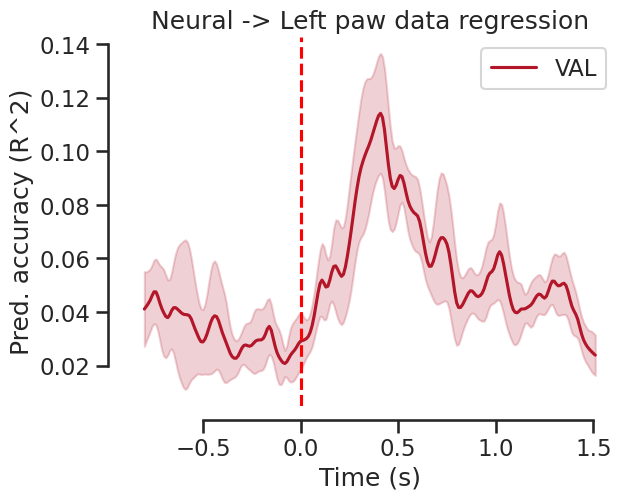

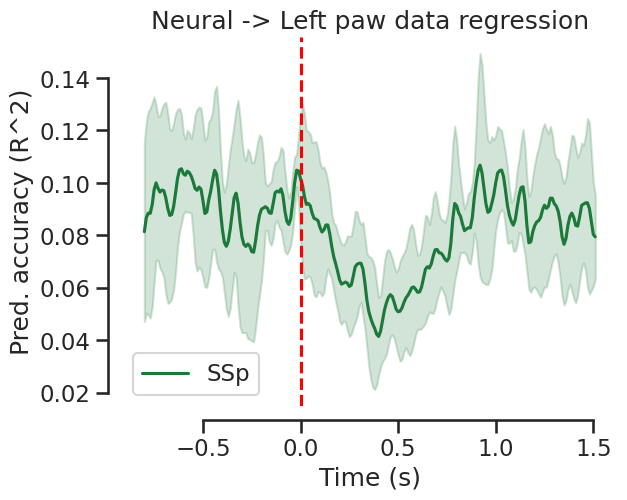

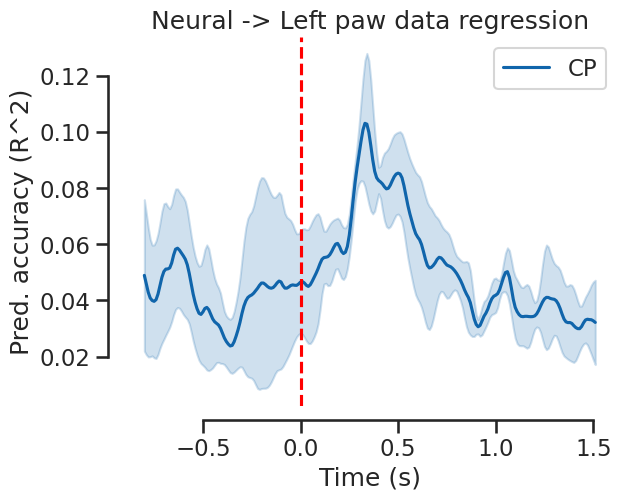

In [18]:
for area in areas:
    with vizutils.apply_plot_style():
        fig, ax = plt.subplots()


        vizutils.shaded_errorbar(ax, times-1, scores_neural_to_bhv[area], label=area, 
                                 color=getattr(colors, area))
    
        ax.axvline(0, color='red', linestyle='dashed')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Pred. accuracy (R^2)')
        ax.legend()
        ax.set_title('Neural -> Left paw data regression')
    
plt.show()


# Encoding / Decoding analysis

## Session M061-1

In [4]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [77]:
x_cv = np.concatenate(perturb_td.bhv.values)
y_cv = np.concatenate(perturb_td.VAL_rates_pca.values)

In [78]:
# Define a range of alpha values to test (logarithmic scale recommended)
alphas = np.logspace(-4, 4, 50)

# RidgeCV performs internal k-fold cross-validation
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True)
ridge_cv.fit(x_cv, y_cv)

best_alpha = ridge_cv.alpha_
print(f"Optimal alpha: {best_alpha:.6f}")

Optimal alpha: 232.995181


In [ ]:
# Retrieve results
cv_errors = ridge_cv.cv_values_  # shape: (n_samples, n_alphas)
mean_cv_errors = np.mean(cv_errors, axis=0)

# Display results
print("Alpha values and their mean CV errors:")
for a, err in zip(alphas, mean_cv_errors):
    print(f"alpha={a:.5f}  mean_CV_error={err:.5f}")

# Plot CV error vs alpha
plt.figure()
plt.semilogx(alphas, mean_cv_errors, marker='o')
plt.axvline(ridge_cv.alpha_, color='red', linestyle='--', label=f'Optimal alpha = {ridge_cv.alpha_:.4f}')
plt.xlabel('Alpha')
plt.ylabel('Mean CV Error')
plt.title('Ridge Regression Cross-Validation Curve')
plt.legend()
plt.show()

In [5]:
left_forelimb = ['left_paw', 'left_elbow', 'left_wrist', 'left_shoulder'] # 'left_elbow_angle', 'left_wrist_angle']
right_forelimb = ['right_paw', 'right_elbow', 'right_wrist', 'right_shoulder'] #, 'right_elbow_angle', 'right_wrist_angle']
forelimbs = left_forelimb + right_forelimb
left_hindlimb = ['left_foot', 'left_knee', 'left_ankle'] 
right_hindlimb = ['right_foot', 'right_knee', 'right_ankle']
hindlimbs = left_hindlimb + right_hindlimb
tail = ['tail_base', 'tail_middle', 'tail_tip']

df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -175, rel_end= 150)
bhv = np.stack(perturb_td.bhv.values)

Dropped 11 of 333 rows (3.30%).
['values_MotSen1_X', 'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center', 'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle', 'left_foot', 'left_knee', 'left_knee_angle', 'left_paw', 'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle', 'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot', 'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder', 'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip', 'all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes', 'all_rates', 'SSp_rates', 'VAL_rates', 'GPe_rates', 'CP_rates', 'MOp_rates', 'SSp_rates_pca', 'VAL_rates_pca', 'GPe_rates_pca', 'CP_rates_pca', 'MOp_rates_pca', 'bhv']


In [6]:
np.stack(perturb_td['right_knee'].values).shape

(322, 326, 3)

In [79]:
scores_bhv_to_neural = {}
areas = ['MOp', 'CP', 'SSp', 'VAL']
for area in areas:
    scores, times = decode.regression_moving_window(
        bhv,
        np.stack(perturb_td[f"{area}_rates_pca"].values),
        window_length_bin=20,
        step_bin=2,
        cv=5,
        alpha=100,
    )
    scores_bhv_to_neural[area] = scores

100%|██████████| 154/154 [00:46<00:00,  3.31it/s]


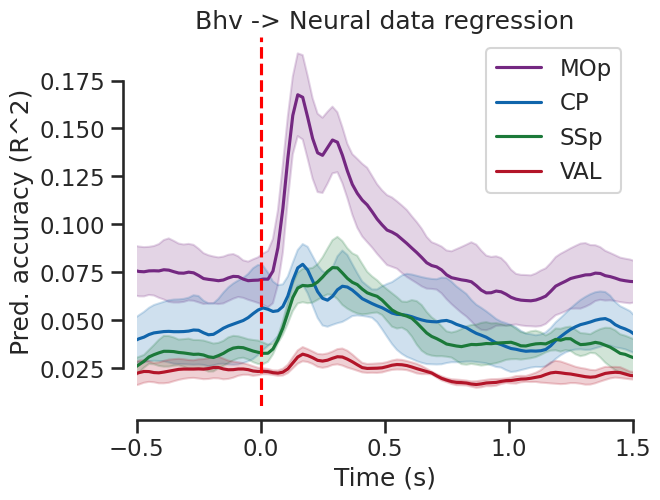

In [80]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        vizutils.shaded_errorbar(ax, times-1.75, 
                                 scores_bhv_to_neural[area], 
                                 label=area, color=getattr(colors, area),
                                 errorStat=np.std)
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (R^2)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('Bhv -> Neural data regression')

plt.show()

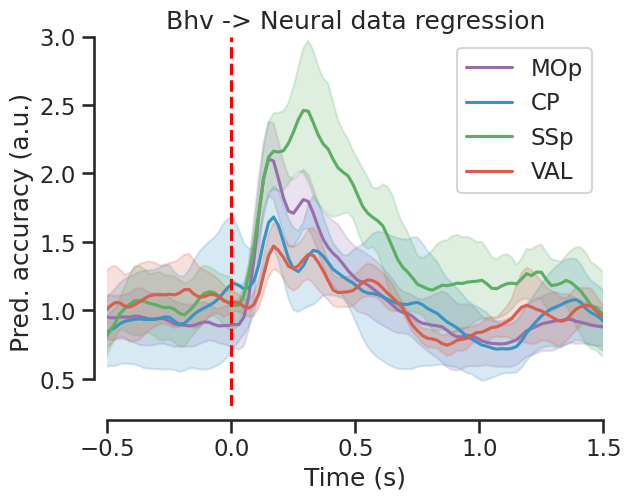

In [81]:
baseline = (-1.5, -0.2)
bmask = (times-1.75 >= baseline[0]) & (times-1.75 <= baseline[1])

with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        baseline_mean = scores_bhv_to_neural[area][bmask].mean(axis=0).mean()
        vizutils.shaded_errorbar(ax, times-1.75, 
                                 scores_bhv_to_neural[area] / baseline_mean, 
                                 label=area, color=getattr(colors, f"{area}_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0.3, 3)

    ax.set_title('Bhv -> Neural data regression')
plt.show()

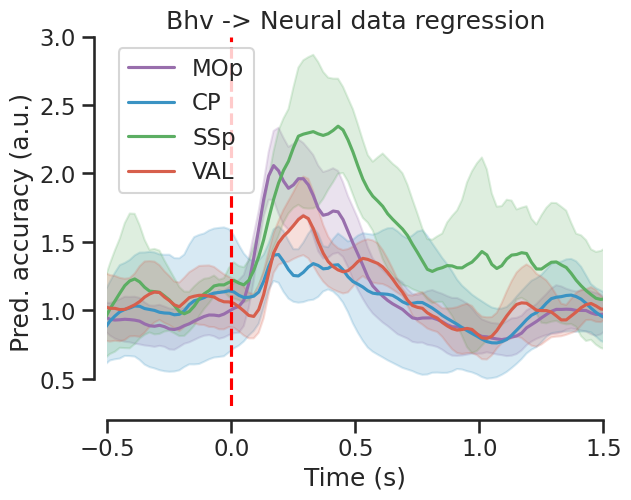

In [54]:
baseline = (-1.5, -0.2)
bmask = (times-1.75 >= baseline[0]) & (times-1.75 <= baseline[1])

with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        baseline_mean = scores_bhv_to_neural[area][bmask].mean(axis=0).mean()
        vizutils.shaded_errorbar(ax, times-1.75, 
                                 scores_bhv_to_neural[area] / baseline_mean, 
                                 label=area, color=getattr(colors, f"{area}_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0.3, 3)

    ax.set_title('Bhv -> Neural data regression')
plt.show()

In [63]:
baseline_mean

0.021632547640176893

In [87]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df, 
                bhv_fields=['left_paw', 'right_paw'])
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end= 200)
bhv = np.stack(perturb_td.bhv.values)

Dropped 11 of 333 rows (3.30%).
['values_MotSen1_X', 'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center', 'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle', 'left_foot', 'left_knee', 'left_knee_angle', 'left_paw', 'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle', 'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot', 'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder', 'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip', 'all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes', 'all_rates', 'SSp_rates', 'VAL_rates', 'GPe_rates', 'CP_rates', 'MOp_rates', 'SSp_rates_pca', 'VAL_rates_pca', 'GPe_rates_pca', 'CP_rates_pca', 'MOp_rates_pca', 'bhv']


In [57]:
scores_neural_to_bhv = {}
areas = ['MOp', 'CP', 'SSp', 'VAL']
for area in areas:
    scores, times = decode.regression_moving_window(
        np.stack(perturb_td[f"{area}_rates_pca"].values),
        bhv,
        window_length_bin=20,
        step_bin=2,
        cv=5
    )
    scores_neural_to_bhv[area] = scores

 38%|███▊      | 59/154 [00:09<00:15,  6.09it/s]


KeyboardInterrupt: 

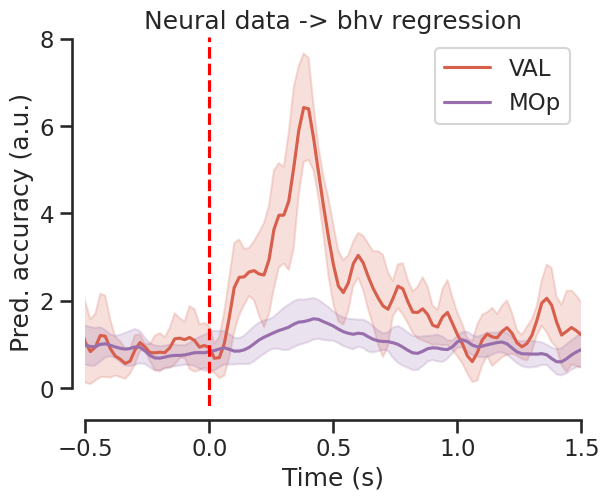

In [90]:
baseline = (-1.5, -0.2)
bmask = (times-2 >= baseline[0]) & (times-2 <= baseline[1])
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in ['VAL', 'MOp']:
        baseline_mean = scores_neural_to_bhv[area][bmask].mean(axis=0).mean()

        vizutils.shaded_errorbar(ax, times-2, 
                                 scores_neural_to_bhv[area] / baseline_mean, 
                                 label=area, color=getattr(colors, f"{area}_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('Neural data -> bhv regression')



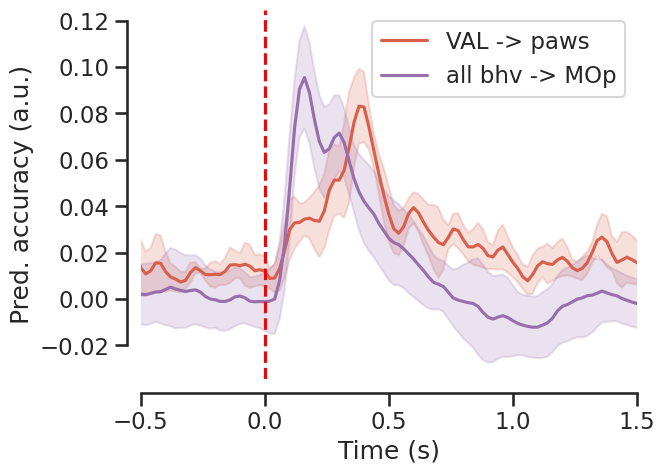

In [99]:
baseline = (-1.5, -0.2)
bmask = (times-2 >= baseline[0]) & (times-2 <= baseline[1])
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    # baseline_mean = scores_neural_to_bhv['VAL'][bmask].mean(axis=0).mean()

    vizutils.shaded_errorbar(ax, times-2, 
                                scores_neural_to_bhv['VAL'], 
                                label='VAL -> paws', color=getattr(colors, f"VAL_light"))
    
    # baseline_mean = scores_bhv_to_neural['MOp'][bmask].mean(axis=0).mean()

    vizutils.shaded_errorbar(ax, times-2, 
                                scores_bhv_to_neural['MOp'] - 0.07, 
                                label='all bhv -> MOp', color=getattr(colors, f"MOp_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    # ax.set_title('Neural data -> bhv regression')



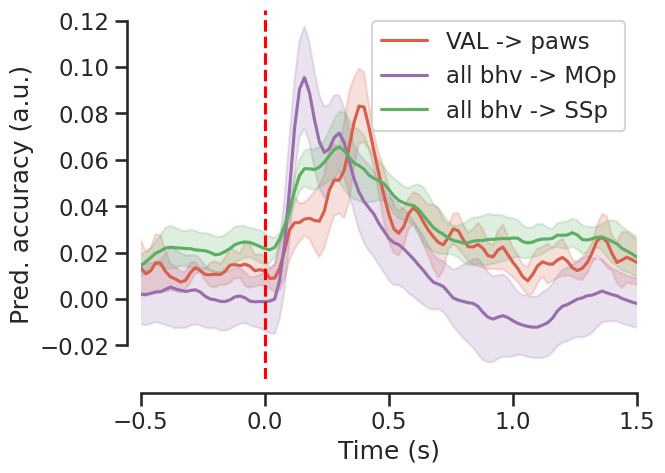

In [103]:
baseline = (-1.5, -0.2)
bmask = (times-2 >= baseline[0]) & (times-2 <= baseline[1])
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    # baseline_mean = scores_neural_to_bhv['VAL'][bmask].mean(axis=0).mean()

    vizutils.shaded_errorbar(ax, times-2, 
                                scores_neural_to_bhv['VAL'], 
                                label='VAL -> paws', color=getattr(colors, f"VAL_light"))
    
    # baseline_mean = scores_bhv_to_neural['MOp'][bmask].mean(axis=0).mean()

    vizutils.shaded_errorbar(ax, times-2, 
                                scores_bhv_to_neural['MOp'] - 0.07, 
                                label='all bhv -> MOp', color=getattr(colors, f"MOp_light"))
    
    vizutils.shaded_errorbar(ax, times-2, 
                                scores_bhv_to_neural['SSp'] - 0.01, 
                                label='all bhv -> SSp', color=getattr(colors, f"SSp_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    # ax.set_title('Neural data -> bhv regression')



In [109]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df, 
                bhv_fields=['left_paw', 'right_paw', 'left_elbow', 'right_elbow'])
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end= 200)
bhv = np.stack(perturb_td.bhv.values)

Dropped 11 of 333 rows (3.30%).
['values_MotSen1_X', 'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center', 'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle', 'left_foot', 'left_knee', 'left_knee_angle', 'left_paw', 'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle', 'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot', 'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder', 'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip', 'all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes', 'all_rates', 'SSp_rates', 'VAL_rates', 'GPe_rates', 'CP_rates', 'MOp_rates', 'SSp_rates_pca', 'VAL_rates_pca', 'GPe_rates_pca', 'CP_rates_pca', 'MOp_rates_pca', 'bhv']


In [110]:
scores_neural_to_bhv_ = {}
areas = ['MOp', 'CP', 'SSp', 'VAL']
for area in areas:
    scores, times = decode.regression_moving_window(
        np.stack(perturb_td[f"{area}_rates_pca"].values),
        bhv,
        window_length_bin=20,
        step_bin=2,
        cv=5
    )
    scores_neural_to_bhv_[area] = scores

100%|██████████| 191/191 [00:30<00:00,  6.28it/s]


In [1]:
baseline = (-1.5, -0.2)
bmask = (times-2 >= baseline[0]) & (times-2 <= baseline[1])
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        baseline_mean = scores_neural_to_bhv_[area][bmask].mean(axis=0).mean()

        vizutils.shaded_errorbar(ax, times-2, 
                                 scores_neural_to_bhv_[area] / baseline_mean, 
                                 label=area, color=getattr(colors, f"{area}_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('Neural data -> bhv regression')



NameError: name 'times' is not defined

## Session M061-2

In [4]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_05_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
['VAL_spikes', 'all_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.84871406959152% of trials
  warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (219, 60000)
Resulting all_spikes ephys data shape is (NxT): (24, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (118, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (100, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (155, 60000)
Resulting CP_spikes ephys data shape is (NxT): (195, 60000)


In [5]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end= 200)
bhv = np.stack(perturb_td.bhv.values)

Dropped 78 of 329 rows (23.71%).
['values_MotSen1_X', 'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center', 'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle', 'left_foot', 'left_knee', 'left_knee_angle', 'left_paw', 'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle', 'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot', 'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder', 'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip', 'VAL_spikes', 'all_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes', 'VAL_rates', 'all_rates', 'SSp_rates', 'GPe_rates', 'MOp_rates', 'CP_rates', 'VAL_rates_pca', 'SSp_rates_pca', 'GPe_rates_pca', 'MOp_rates_pca', 'CP_rates_pca', 'bhv']


In [6]:
scores_bhv_to_neural = {}
areas = ['MOp', 'CP', 'SSp', 'VAL']
for area in areas:
    scores, times = decode.regression_moving_window(
        bhv,
        np.stack(perturb_td[f"{area}_rates_pca"].values),
        window_length_bin=20,
        step_bin=2,
        cv=5
    )
    scores_bhv_to_neural[area] = scores

100%|██████████| 191/191 [00:19<00:00,  9.76it/s]


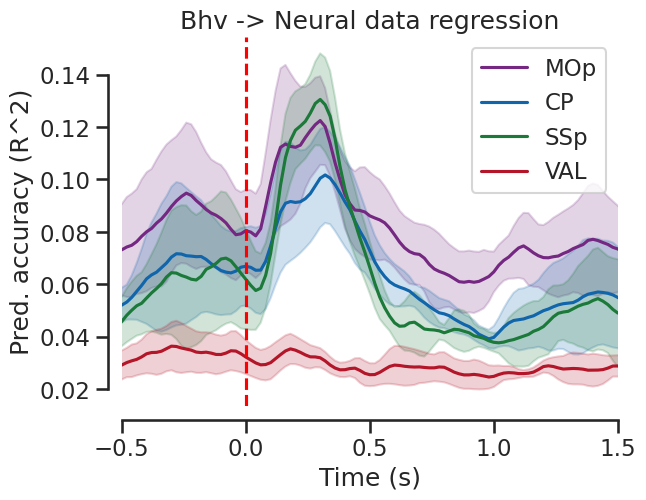

In [7]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        vizutils.shaded_errorbar(ax, times-2, 
                                 scores_bhv_to_neural[area], 
                                 label=area, color=getattr(colors, area))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (R^2)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('Bhv -> Neural data regression')



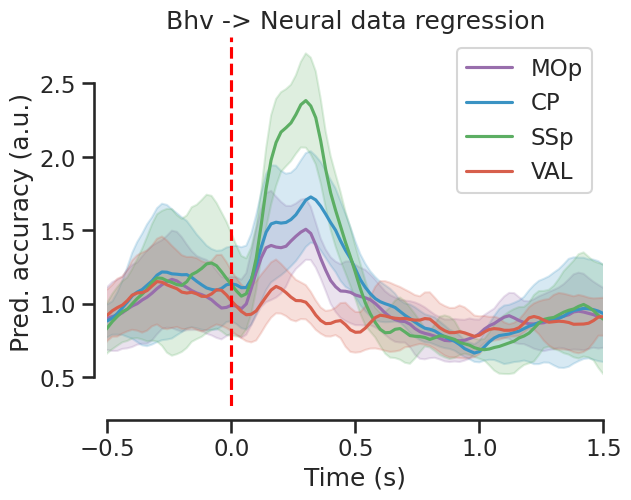

In [10]:
baseline = (-1.5, -0.2)
bmask = (times-2 >= baseline[0]) & (times-2 <= baseline[1])

with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        baseline_mean = scores_bhv_to_neural[area][bmask].mean(axis=0).mean()
        vizutils.shaded_errorbar(ax, times-2, 
                                 scores_bhv_to_neural[area] / baseline_mean, 
                                 label=area, color=getattr(colors, f"{area}_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('Bhv -> Neural data regression')
plt.show()

In [51]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df, bhv_fields=['left_knee', 'right_knee', 'left_ankle', 'right_ankle'])
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -175, rel_end= 150)
bhv = np.stack(perturb_td.bhv.values)

Dropped 78 of 329 rows (23.71%).
['values_MotSen1_X', 'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center', 'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle', 'left_foot', 'left_knee', 'left_knee_angle', 'left_paw', 'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle', 'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot', 'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder', 'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip', 'VAL_spikes', 'all_spikes', 'SSp_spikes', 'GPe_spikes', 'MOp_spikes', 'CP_spikes', 'VAL_rates', 'all_rates', 'SSp_rates', 'GPe_rates', 'MOp_rates', 'CP_rates', 'VAL_rates_pca', 'SSp_rates_pca', 'GPe_rates_pca', 'MOp_rates_pca', 'CP_rates_pca', 'bhv']


In [52]:
scores_neural_to_bhv = {}
areas = ['MOp', 'CP', 'SSp', 'VAL']
for area in areas:
    scores, times = decode.regression_moving_window(
        np.stack(perturb_td[f"{area}_rates_pca"].values),
        bhv,
        window_length_bin=20,
        step_bin=2,
        cv=5
    )
    scores_neural_to_bhv[area] = scores

  0%|          | 0/154 [00:00<?, ?it/s]

100%|██████████| 154/154 [00:32<00:00,  4.69it/s]


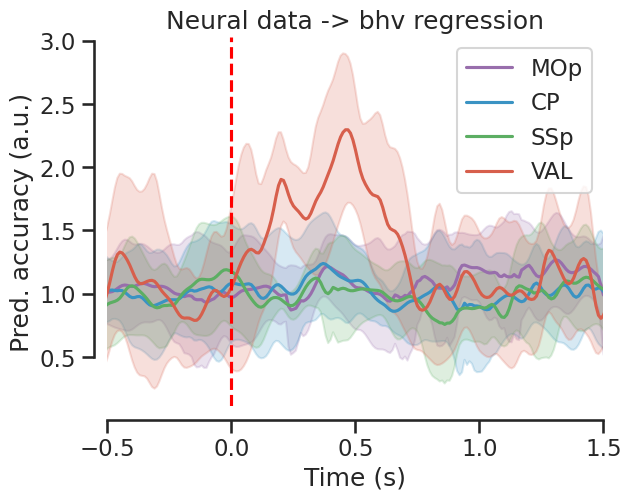

In [50]:
baseline = (-1.5, -0.2)
bmask = (times-1.75 >= baseline[0]) & (times-1.75 <= baseline[1])
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        baseline_mean = scores_neural_to_bhv[area][bmask].mean(axis=0).mean()

        vizutils.shaded_errorbar(ax, times-1.75, 
                                 scores_neural_to_bhv[area] / baseline_mean, 
                                 label=area, color=getattr(colors, f"{area}_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('Neural data -> bhv regression')

plt.show()

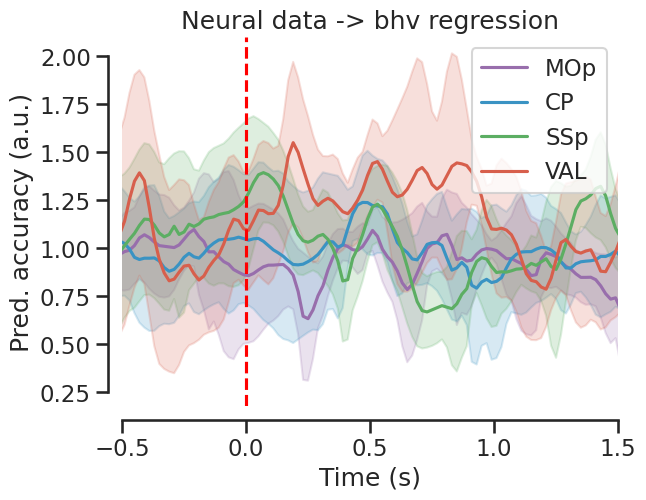

In [53]:
baseline = (-1.5, -0.2)
bmask = (times-1.75 >= baseline[0]) & (times-1.75 <= baseline[1])
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        baseline_mean = scores_neural_to_bhv[area][bmask].mean(axis=0).mean()

        vizutils.shaded_errorbar(ax, times-1.75, 
                                 scores_neural_to_bhv[area] / baseline_mean, 
                                 label=area, color=getattr(colors, f"{area}_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('Neural data -> bhv regression')

plt.show()

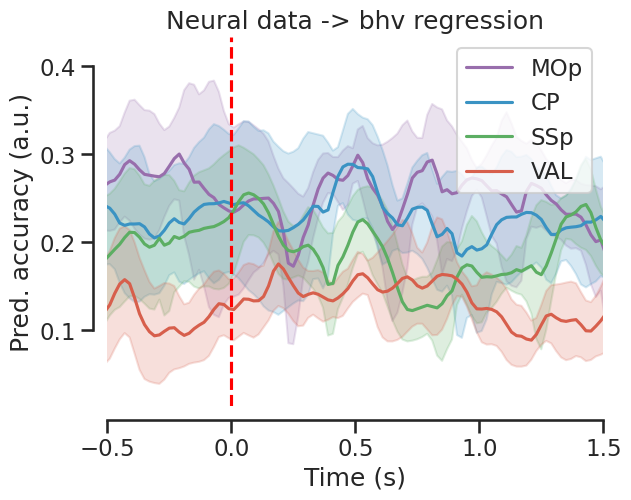

In [54]:
baseline = (-1.5, -0.2)
bmask = (times-1.75 >= baseline[0]) & (times-1.75 <= baseline[1])
with vizutils.apply_plot_style():
    fig, ax = plt.subplots()
    for area in areas:
        baseline_mean = scores_neural_to_bhv[area][bmask].mean(axis=0).mean()

        vizutils.shaded_errorbar(ax, times-1.75, 
                                 scores_neural_to_bhv[area], 
                                 label=area, color=getattr(colors, f"{area}_light"))
    
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Pred. accuracy (a.u.)')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('Neural data -> bhv regression')

plt.show()

## Session M061-3

In [ ]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_05_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()
